In [21]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100,'reso':'xx-hi'})

In [22]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
SRCONFIG   = MODELS['sr']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'valid'
VARLABELS  = {
    'bl':'$B_L$ (m/s$^2$)',
    'cape':'$CAPE_L$ (K)',
    'subsat':'$SUBSAT_L$ (K)',
    'rh':'RH (%)',
    'thetae':r'$\mathit{\theta_{e}}$ (K)',
    'thetaestar':r'$\mathit{\theta_{e}}^*$ (K)',
    'lf':'Land Fraction',
    'shf':'Surface Sensible Heat Flux (W/m$^2$)',
    'lhf':'Surface Latent Heat Flux (W/m$^2$)'}
PLOTSTYLE  = {
    'pod':('gray6','POD'),
    'baseline':('blue6','Baseline NN'),
    'nonparametric':('yellow3','Nonparametric Kernel NN'),
    'parametric':('red6','Parametric Kernel NN'),
    'sr':('green7','Symbolic Regression')}

In [23]:
def get_kind(name):
    for group in ['pod','nn','sr']:
        runs = MODELS.get(group,{}).get('runs',{})
        if name in runs:
            if group in ('pod','sr'):
                return group
            return runs[name]['kind']
    return 'unknown'

def get_global_range(results):
    allvals = []
    for ytrue,ypred in results.values():
        allvals.append(ytrue.values.ravel())
        allvals.append(ypred.values.ravel())
    allvals = np.concatenate(allvals)
    allvals = allvals[np.isfinite(allvals)&(allvals>0)]
    return allvals.min(),allvals.max()

def get_r2(ytrue,ypred,dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    ssres = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return 1-ssres/sstot

def get_mse(ytrue,ypred,dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    return ((ytrue-ypred)**2).mean(dim=dims,skipna=True)

def get_nn_complexity(kind,nfieldvars,nlevs,nlocalvars):
    def nparams(nfeatures):
        return (nfeatures*256)+256+(256*128)+128+(128*64)+64+(64*32)+32+(32*1)+1
    if kind=='baseline':
        return nparams(nfieldvars*nlevs+nlocalvars)
    elif kind=='nonparametric':
        return nfieldvars*nlevs+nparams(nfieldvars+nlocalvars)
    elif kind=='parametric':
        return 2*nfieldvars+nparams(nfieldvars+nlocalvars)

In [24]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for group in ['pod','nn','sr']:
    for name in MODELS[group]['runs']:
        filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
        if os.path.exists(filepath):
            with xr.open_dataset(filepath) as ds:
                predtp = ds.tp.load()
            ytrue,ypred = xr.align(truetp,predtp,join='inner')
            results[name] = (ytrue,ypred)
print(f'Found {len(results)} models with predictions!')

globalmin,globalmax = get_global_range(results)
print(f'tp range: [{globalmin:.2e}, {globalmax:.2e}]')

Found 13 models with predictions!
tp range: [2.98e-08, 1.40e+02]


In [25]:
def plot_pareto(results):
    with xr.open_dataset(os.path.join(SPLITSDIR, 'norm_train.h5'),engine='h5netcdf') as ds:
        firstvar = next(iter(MODELS['nn']['runs'].values()))['fieldvars'][0]
        nsigs = ds.sizes['sig'] if 'sig' in ds[firstvar].dims else 1

    records = []
    r2_half_mses = []

    for name, (ytrue, ypred) in results.items():
        ypredmean = ypred.mean('seed') if 'seed' in ypred.dims else ypred

        r2 = float(get_r2(ytrue, ypredmean))
        mse = float(get_mse(ytrue, ypredmean))

        # MSE value equivalent to R^2 = 0.5 for this target field
        r2_half_mse = float(get_mse_at_r2(ytrue, r2_target=0.5))
        r2_half_mses.append(r2_half_mse)

        if name in MODELS.get('pod', {}).get('runs', {}):
            with np.load(os.path.join(MODELSDIR, 'pod', f'{name}.npz')) as d:
                nparams = int(d['nparams'])
            kind = 'pod'

        elif name in MODELS.get('sr', {}).get('runs', {}):
            csvpath = os.path.join(MODELSDIR, 'sr', f'{name}_equations.csv')
            eqdf = pd.read_csv(csvpath)
            nparams = int(eqdf.sort_values('loss').iloc[0]['complexity'])
            kind = 'sr'

        else:
            config = MODELS['nn']['runs'][name]
            kind = config['kind']
            fieldvars, localvars = config['fieldvars'], config.get('localvars', [])
            nparams = get_nn_complexity(kind, len(fieldvars), nsigs, len(localvars))

        color, label = PLOTSTYLE.get(kind, ('gray6', kind))

        records.append(dict(
            name=name,
            r2=r2,
            mse=mse,
            nparams=nparams,
            color=color,
            label=label,
            kind=kind,
        ))

    fig, ax = pplt.subplots(refwidth=4, refheight=2)

    ax.format(
        suptitle='Pareto Plot',
        grid=True,
        xlabel='MSE',
        xscale='log',
        xformatter='log',
        ylabel='Model Complexity',
        yscale='log',
        yformatter='log',
    )

    seen = set()
    for rec in records:
        label = rec['label'] if rec['label'] not in seen else None
        marker = '*' if rec['kind'] == 'sr' else 'o'
        ms = 80 if rec['kind'] == 'sr' else 20

        ax.scatter(
            rec['mse'],
            rec['nparams'],
            color=rec['color'],
            zorder=3,
            label=label,
            marker=marker,
            s=ms,
        )
        seen.add(rec['label'])

    for rec in records:
        ax.annotate(
            rec['name'],
            (rec['mse'], rec['nparams']),
            xytext=(4, 3),
            textcoords='offset points',
            fontsize=6,
        )

    # Vertical line(s) where R^2 = 0.5.
    # If all targets share the same variance, this will draw one line.
    for i, mse_line in enumerate(sorted(set(np.round(r2_half_mses, 12)))):
        ax.axvline(
            mse_line,
            color='k',
            linestyle=':',
            linewidth=1,
            label='R$^2$ = 0.5' if i == 0 else None,
        )

    front = pareto_front(records)
    if len(front) > 1:
        ax.plot([r['mse'] for r in front],[r['nparams'] for r in front],'k--',label='Pareto Front')
    ax.legend(loc='r', ncols=1)
    pplt.show()


def pareto_front(records):
    # Lower MSE and lower complexity are better.
    ordered = sorted(records, key=lambda r: r['mse'])
    front = []
    best_complexity = np.inf

    for r in ordered:
        if r['nparams'] < best_complexity:
            front.append(r)
            best_complexity = r['nparams']

    return front


def get_mse_at_r2(ytrue, r2_target=0.5, dims=None):
    dims = list(ytrue.dims) if dims is None else dims

    sstot = ((ytrue - ytrue.mean(dim=dims, skipna=True)) ** 2).sum(dim=dims, skipna=True)
    n = ytrue.count(dim=dims)

    return (1 - r2_target) * sstot / n

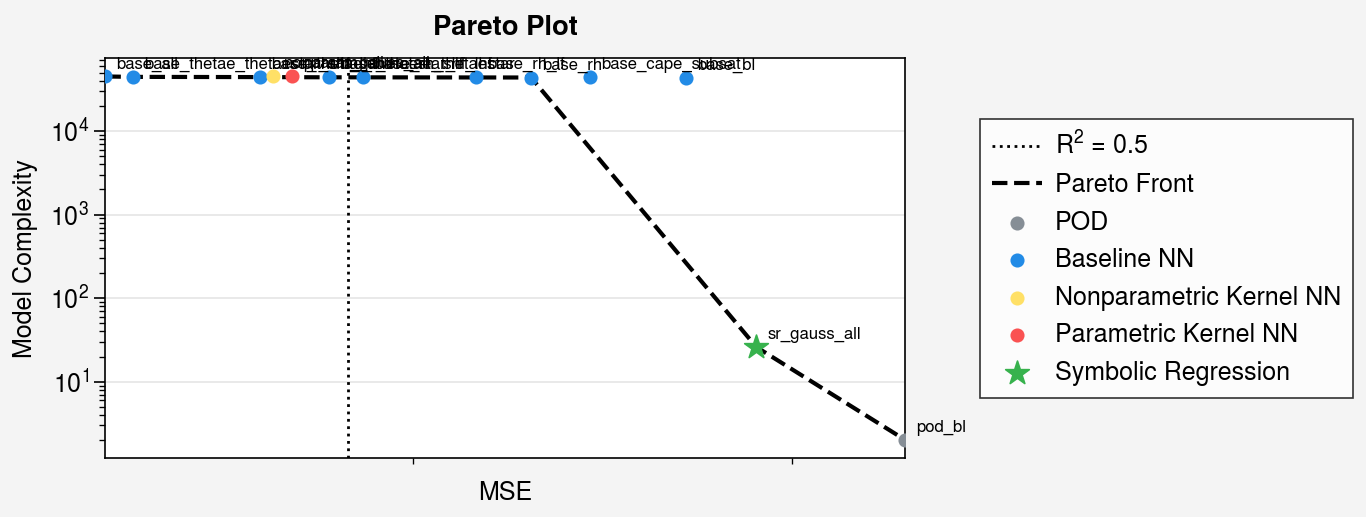

In [26]:
plot_pareto(results)

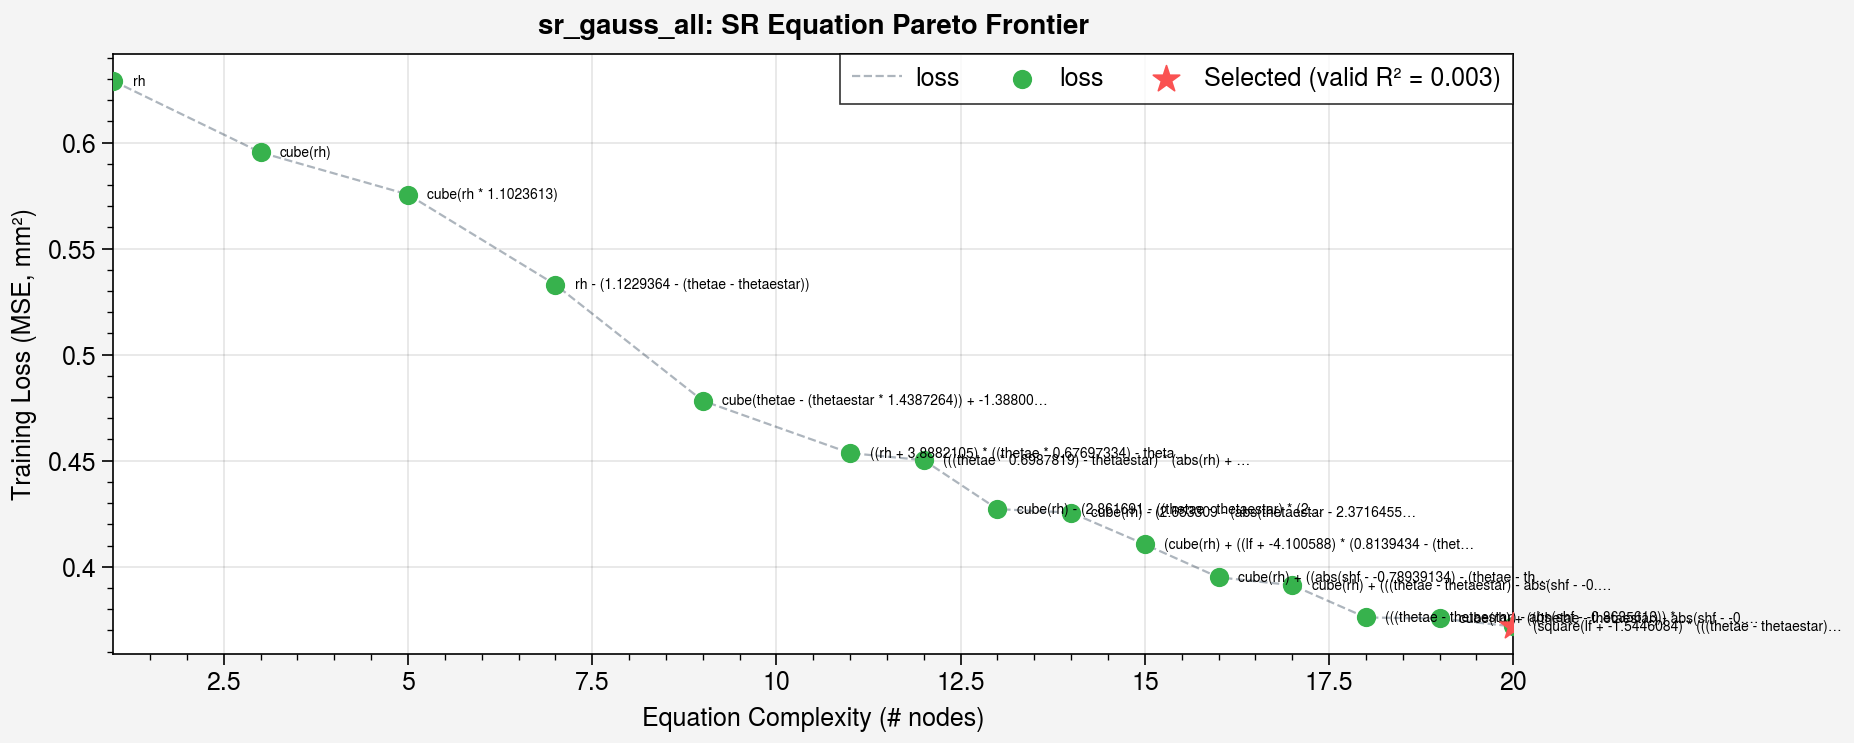

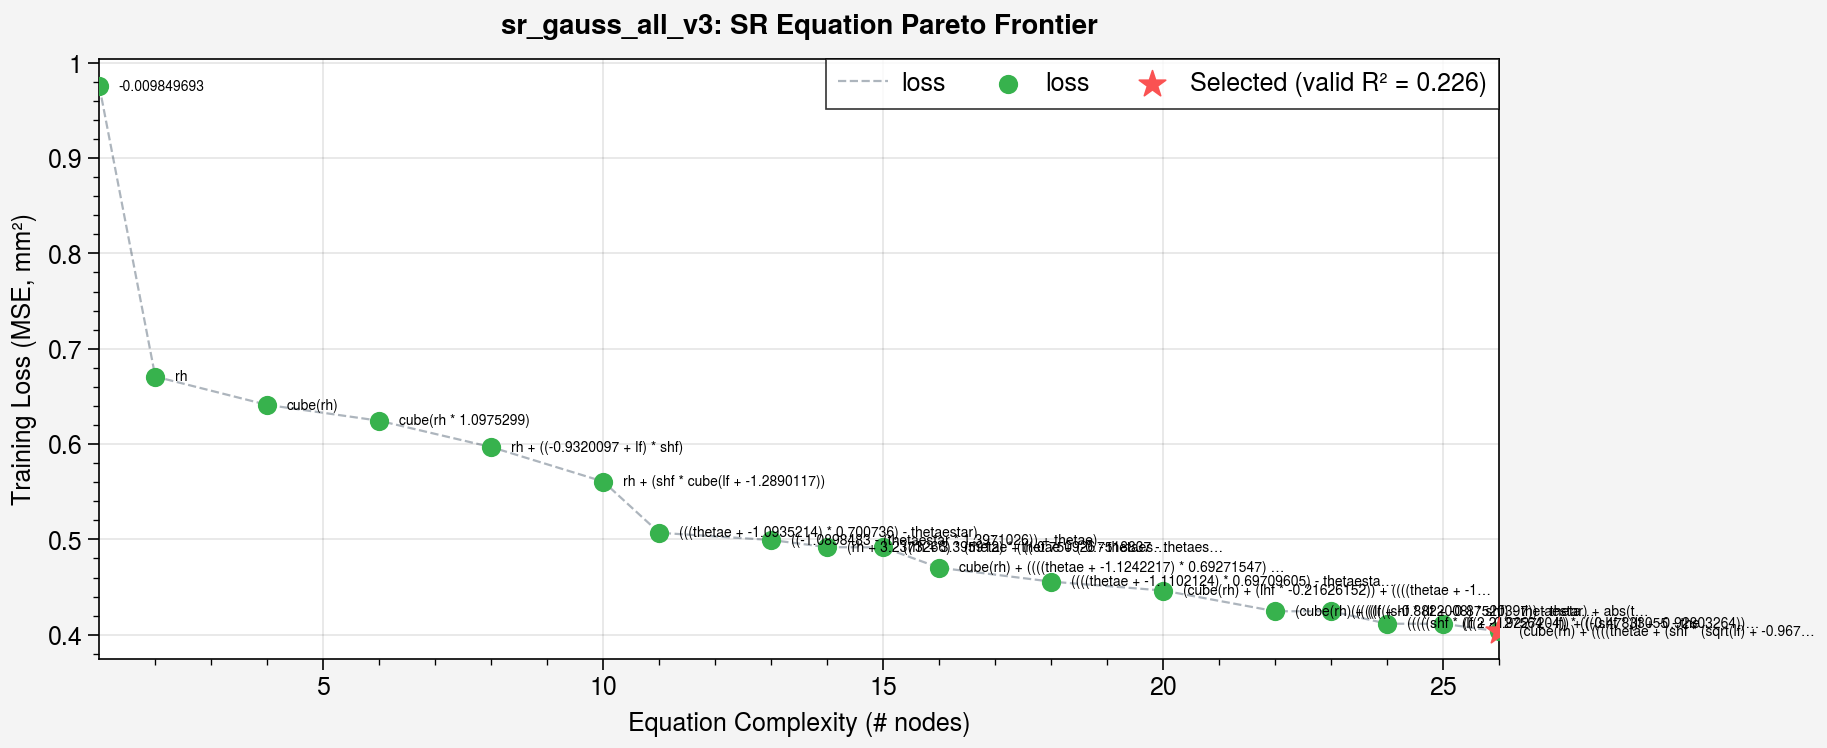

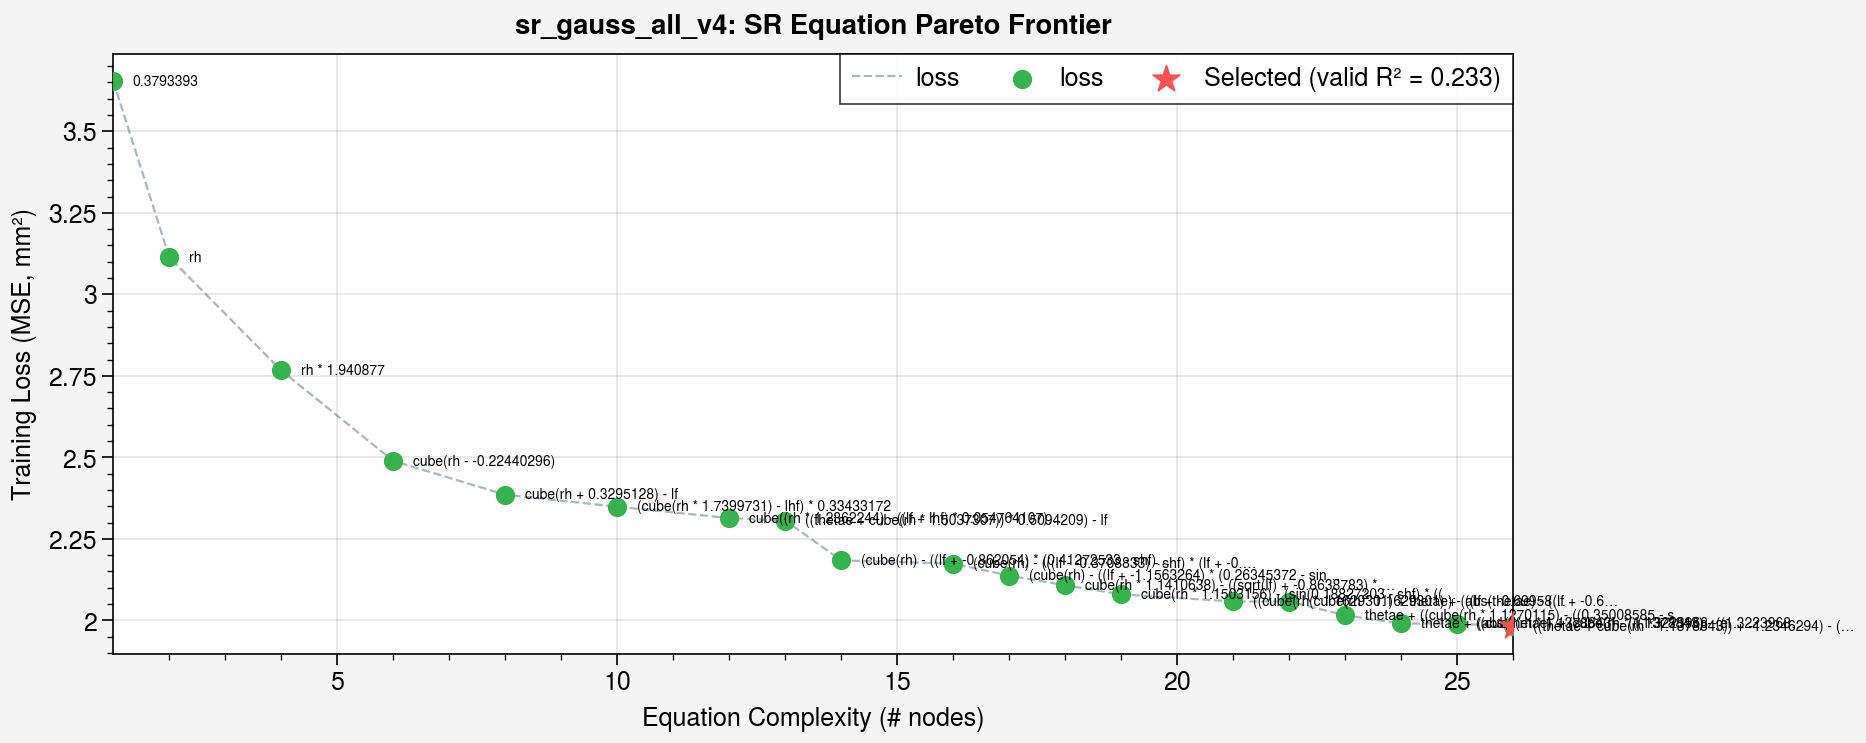

In [17]:
plot_pareto_equations(results)